# 03 - D Module Figures and Interpretation

This notebook presents D-module as the project's diagnostic and interpretation layer.

The central question is not whether D can make tables and plots. It can. The real question is what those outputs imply about the current state of the model.

That is the purpose of this notebook: to turn the raw CSV and PNG outputs into a defensible project-level reading.


## Key takeaways before reading the outputs

The current D-module outputs support two simultaneous conclusions, and the calibration round now sharpens that into a two-run display framework.

Positive conclusion:
- The project already has a functioning evaluation layer with risk metrics, distribution comparison, and what-if attribution.

Critical conclusion:
- The current trained generator is still materially miscalibrated relative to the real test distribution.

Calibration display conclusion:
- `seed_42_tailw_1.0` is the run to emphasize when overall distribution distance is the primary criterion.
- `seed_42_tailw_3.0` is the run to emphasize when ES alignment is the primary criterion.
- If both objectives must improve together, the next stage should move beyond seed and tail-weight tuning toward condition expansion or backbone upgrade.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if Path('data').exists() and Path('outputs').exists():
    PROJECT_ROOT = Path.cwd()
elif Path.cwd().name == 'notebooks' and Path('../data').exists() and Path('../outputs').exists():
    PROJECT_ROOT = Path.cwd().parent
else:
    raise FileNotFoundError('Cannot locate project root from current notebook working directory.')

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)


In [2]:
TABLE_DIR = PROJECT_ROOT / 'outputs/tables'
FIG_DIR = PROJECT_ROOT / 'outputs/figures'
CAL_DIR = PROJECT_ROOT / 'outputs/calibration'
summary_path = CAL_DIR / 'calibration_summary.csv'
assert summary_path.exists(), f'Missing calibration summary: {summary_path}'
calib_df = pd.read_csv(summary_path)
selected_runs = calib_df[((calib_df['seed'] == 42) & (calib_df['tail_weight'].isin([1.0, 3.0])))].copy()
selected_runs = selected_runs.sort_values(['tail_weight']).reset_index(drop=True)
assert selected_runs.shape[0] == 2, 'Expected calibration anchors for seed_42_tailw_1.0 and seed_42_tailw_3.0'
dist_row = selected_runs.loc[selected_runs['tail_weight'] == 1.0].iloc[0]
tail_row = selected_runs.loc[selected_runs['tail_weight'] == 3.0].iloc[0]
dist_run_dir = PROJECT_ROOT / dist_row['run_dir']
tail_run_dir = PROJECT_ROOT / tail_row['run_dir']
dist_real_df = pd.read_csv(dist_run_dir / 'tables' / 'd_real_risk_metrics.csv')
dist_gen_df = pd.read_csv(dist_run_dir / 'tables' / 'd_generated_risk_metrics.csv')
dist_cmp_df = pd.read_csv(dist_run_dir / 'tables' / 'd_distribution_compare.csv')
tail_real_df = pd.read_csv(tail_run_dir / 'tables' / 'd_real_risk_metrics.csv')
tail_gen_df = pd.read_csv(tail_run_dir / 'tables' / 'd_generated_risk_metrics.csv')
tail_cmp_df = pd.read_csv(tail_run_dir / 'tables' / 'd_distribution_compare.csv')
attr_path = TABLE_DIR / 'd_factor_sensitivity.csv'
meta_path = TABLE_DIR / 'd_factor_sensitivity_meta.json'
attr_available = attr_path.exists() and meta_path.exists()
attr_df = pd.read_csv(attr_path) if attr_available else pd.DataFrame()
display(calib_df[['seed', 'tail_weight', 'mean_wasserstein', 'mean_abs_es_gap', 'mean_abs_var_gap', 'rank']].sort_values('rank'))
display(selected_runs[['seed', 'tail_weight', 'mean_wasserstein', 'mean_abs_es_gap', 'mean_abs_var_gap', 'rank']])


,seed,tail_weight,mean_wasserstein,mean_abs_es_gap,mean_abs_var_gap,rank
0,42,1.0,22.519569,65.531595,50.177696,1
1,42,3.0,24.413426,40.586122,27.084534,2
2,42,5.0,26.660544,59.561607,45.080790,3
3,62,1.0,29.224941,90.870091,74.704508,4
4,62,3.0,33.087754,89.728486,70.158946,5
5,62,5.0,38.249284,91.088546,65.088495,6
6,52,1.0,43.913174,122.011700,95.669688,7
7,52,3.0,44.483896,127.610061,106.297635,8
8,52,5.0,47.340619,137.370611,113.619762,9


,seed,tail_weight,mean_wasserstein,mean_abs_es_gap,mean_abs_var_gap,rank
0,42,1.0,22.519569,65.531595,50.177696,1
1,42,3.0,24.413426,40.586122,27.084534,2


## 1) Two calibration anchors: distribution fit versus ES alignment

This notebook should not frame the calibration outcome as a single-winner story. The more honest reading is that the calibration round identified two useful anchors.

How to read them:
- `seed_42_tailw_1.0` is the better display run when the project wants to emphasize overall distribution-distance improvement.
- `seed_42_tailw_3.0` is the better display run when the project wants to emphasize tail-risk metric alignment, especially ES.

What this means for interpretation:
- Calibration improved the project from a single default setting to an explicit tradeoff map.
- The project now knows that distribution fit and ES alignment do not improve in exactly the same way under seed/weight tuning.
- That tradeoff is itself a useful result, because it defines the next research decision clearly.


,horizon,baseline_scope,alpha,count,mean,std,var_alpha,es_alpha,var_5pct,es_5pct,worst
0,last_day,overall_test,0.05,544,0.000779,0.018294,-0.022908,-0.036805,-0.022908,-0.036805,-0.10832
1,cum_20d,overall_test,0.05,544,0.017537,0.082523,-0.082707,-0.107793,-0.082707,-0.107793,-0.16119


,calibration_anchor,condition,checkpoint,horizon,alpha,mean,var_alpha,es_alpha,worst
1,distribution_priority_42_1.0,high_risk_market,best,cum_20d,0.05,-9.877492,-72.342747,-95.908566,-216.230179
3,distribution_priority_42_1.0,normal_market,best,cum_20d,0.05,-6.948505,-81.044963,-104.415474,-142.176971
5,es_priority_42_3.0,high_risk_market,best,cum_20d,0.05,22.874036,-32.424483,-53.414916,-96.039940
7,es_priority_42_3.0,normal_market,best,cum_20d,0.05,23.362602,-34.957011,-56.564760,-129.795319
0,distribution_priority_42_1.0,high_risk_market,best,last_day,0.05,2.863459,-23.267954,-31.606487,-55.516193
2,distribution_priority_42_1.0,normal_market,best,last_day,0.05,2.021477,-24.266350,-30.485048,-43.934391
4,es_priority_42_3.0,high_risk_market,best,last_day,0.05,6.679576,-21.148838,-26.481510,-49.411137
6,es_priority_42_3.0,normal_market,best,last_day,0.05,6.482248,-20.019032,-26.172498,-42.529579


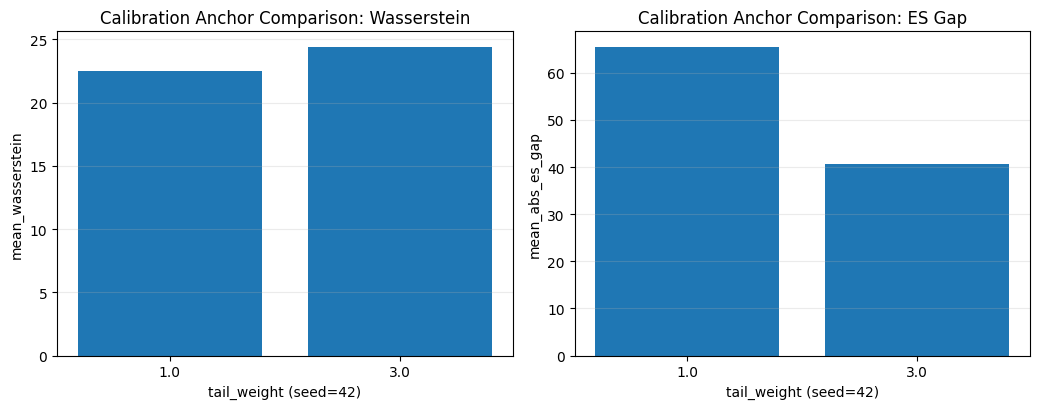

In [3]:
anchor_cols = ['condition', 'checkpoint', 'horizon', 'alpha', 'mean', 'var_alpha', 'es_alpha', 'worst']
dist_short = dist_gen_df[anchor_cols].copy()
dist_short['calibration_anchor'] = 'distribution_priority_42_1.0'
tail_short = tail_gen_df[anchor_cols].copy()
tail_short['calibration_anchor'] = 'es_priority_42_3.0'
anchor_compare = pd.concat([dist_short, tail_short], ignore_index=True)
display(dist_real_df)
display(anchor_compare[['calibration_anchor', *anchor_cols]].sort_values(['horizon', 'calibration_anchor', 'condition']))
metric_bar = selected_runs[['tail_weight', 'mean_wasserstein', 'mean_abs_es_gap']].copy()
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
axes[0].bar(metric_bar['tail_weight'].astype(str), metric_bar['mean_wasserstein'])
axes[0].set_title('Calibration Anchor Comparison: Wasserstein')
axes[0].set_xlabel('tail_weight (seed=42)')
axes[0].set_ylabel('mean_wasserstein')
axes[1].bar(metric_bar['tail_weight'].astype(str), metric_bar['mean_abs_es_gap'])
axes[1].set_title('Calibration Anchor Comparison: ES Gap')
axes[1].set_xlabel('tail_weight (seed=42)')
axes[1].set_ylabel('mean_abs_es_gap')
for ax in axes:
    ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


## 2) Distribution mismatch diagnostics under the two-anchor framework

Risk metrics alone can miss shape differences, so the calibration interpretation must also look at KS and Wasserstein diagnostics.

Why these diagnostics matter:
- `ks_stat` measures global distribution mismatch.
- `ks_pvalue` indicates whether the mismatch is negligible or clearly real.
- `wasserstein_distance` gives a transport-style notion of how far the distributions are apart in scale.

How to read the two anchors:
- `42 / 1.0` is the distribution-distance priority run and should look better on Wasserstein-style comparison.
- `42 / 3.0` is the ES-priority run and can still remain competitive overall, but its main value is tighter tail-risk alignment rather than best transport distance.

This is the key calibration lesson: tuning can shift which quality dimension improves first, but it does not fully solve both at once.


In [4]:
dist_cmp_short = dist_cmp_df[['condition', 'checkpoint', 'horizon', 'ks_stat', 'ks_pvalue', 'spearman_hist', 'wasserstein_distance']].copy()
dist_cmp_short['calibration_anchor'] = 'distribution_priority_42_1.0'
tail_cmp_short = tail_cmp_df[['condition', 'checkpoint', 'horizon', 'ks_stat', 'ks_pvalue', 'spearman_hist', 'wasserstein_distance']].copy()
tail_cmp_short['calibration_anchor'] = 'es_priority_42_3.0'
cmp_short = pd.concat([dist_cmp_short, tail_cmp_short], ignore_index=True)
display(cmp_short.sort_values(['horizon', 'calibration_anchor', 'condition', 'checkpoint']))


,condition,checkpoint,horizon,ks_stat,ks_pvalue,spearman_hist,wasserstein_distance,calibration_anchor
1,high_risk_market,best,cum_20d,0.611,1.454264e-123,0.367141,30.074142,distribution_priority_42_1.0
3,normal_market,best,cum_20d,0.565,1.789728e-104,0.270514,33.552985,distribution_priority_42_1.0
5,high_risk_market,best,cum_20d,0.733,4.927750e-185,0.306487,33.881358,es_priority_42_3.0
7,normal_market,best,cum_20d,0.745,4.468145e-192,0.104058,34.612046,es_priority_42_3.0
0,high_risk_market,best,last_day,0.555,1.390509e-100,0.124882,13.349522,distribution_priority_42_1.0
2,normal_market,best,last_day,0.521,5.191010e-88,0.242826,13.101625,distribution_priority_42_1.0
4,high_risk_market,best,last_day,0.621,5.479884e-128,0.201227,14.741310,es_priority_42_3.0
6,normal_market,best,last_day,0.613,1.931907e-124,0.215104,14.418991,es_priority_42_3.0


## 3) Condition comparison plots

The next question is whether the conditional interface is doing anything meaningful at all.

What these plots help answer:
- Do different conditions produce different risk outcomes?
- Even if the model is miscalibrated overall, is the conditioning channel at least active?

How to interpret the current figures:
- If the bars differ by condition, then the model is responding to conditional inputs.
- If they all collapse to the same level, the conditional mechanism is effectively ignored.

In the current project state, the model does show condition-dependent variation. That is encouraging. The problem is that this variation still sits on top of a shifted distribution. The calibration result therefore changes the question from "does conditioning work at all" to "can the project preserve conditional responsiveness while improving either distribution fit or ES alignment."


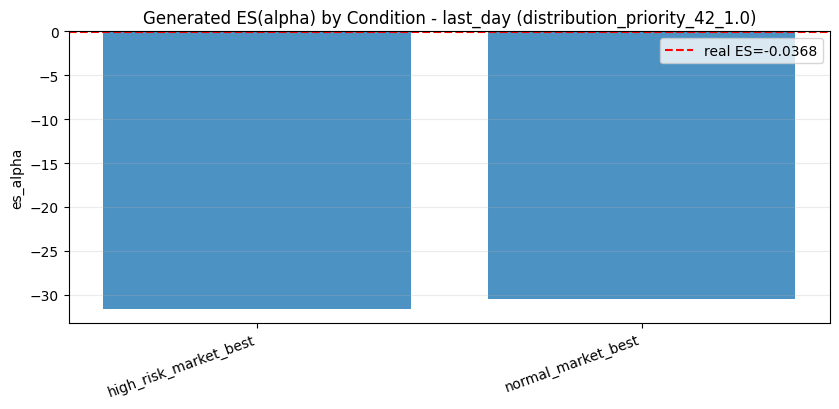

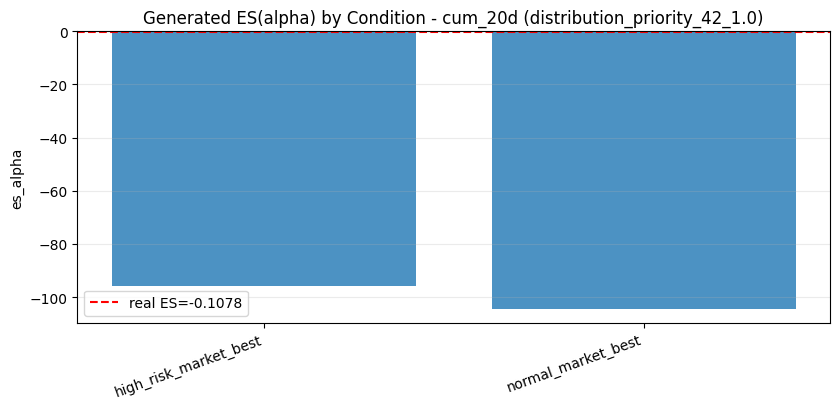

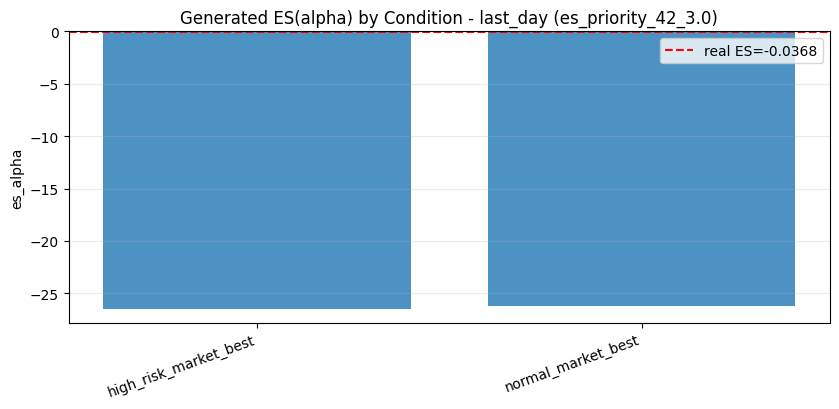

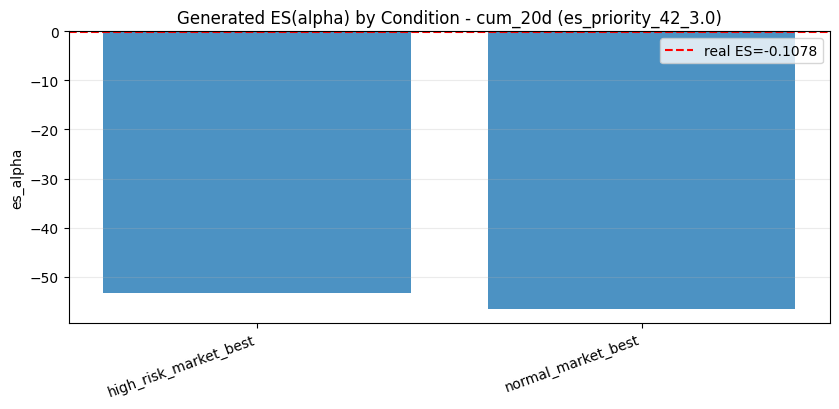

In [5]:
def es_bar_from_table(real_df: pd.DataFrame, gen_df: pd.DataFrame, horizon: str, anchor_label: str) -> None:
    real_es = float(real_df.loc[real_df['horizon'] == horizon, 'es_alpha'].iloc[0])
    sub = gen_df[gen_df['horizon'] == horizon].copy().sort_values(['condition', 'checkpoint'])
    labels = (sub['condition'] + '_' + sub['checkpoint']).tolist()
    values = sub['es_alpha'].astype(float).to_numpy()

    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    ax.bar(np.arange(len(labels)), values, alpha=0.8)
    ax.axhline(real_es, color='red', linestyle='--', linewidth=1.5, label=f'real ES={real_es:.4f}')
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=20, ha='right')
    ax.set_title(f'Generated ES(alpha) by Condition - {horizon} ({anchor_label})')
    ax.set_ylabel('es_alpha')
    ax.grid(axis='y', alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

es_bar_from_table(dist_real_df, dist_gen_df, 'last_day', 'distribution_priority_42_1.0')
es_bar_from_table(dist_real_df, dist_gen_df, 'cum_20d', 'distribution_priority_42_1.0')
es_bar_from_table(tail_real_df, tail_gen_df, 'last_day', 'es_priority_42_3.0')
es_bar_from_table(tail_real_df, tail_gen_df, 'cum_20d', 'es_priority_42_3.0')


## 4) What the attribution module is really telling us

Attribution is easy to oversell, so this section needs careful wording.

What the current attribution module is:
- A condition-level what-if sensitivity analysis.
- It perturbs one condition factor while holding a base condition template fixed.
- It then measures how risk outputs move.

What it is not:
- It is not a pathwise reverse-diffusion attribution method.
- It is not yet a causal explanation of why a particular generated path occurred.

How calibration changes the reading of this section:
- The calibration archive itself is evaluation-only and does not include attribution sweeps.
- Attribution should therefore be read as a complementary D-module capability, not as part of the calibration ranking table.
- If attribution files are absent from the live outputs folder, that means calibration has refreshed the runtime outputs and a standalone attribution run is needed.


,checkpoint,base_condition,factor,factor_value,horizon,alpha,count,mean,std,var_alpha,es_alpha,var_5pct,es_5pct,worst,delta_var_5pct,delta_es_5pct
0,latest,normal_market,baseline,0.0,last_day,0.05,256,-3.040449,15.899319,-30.075406,-34.540154,-30.075406,-34.540154,-46.163197,0.000000,0.000000
1,latest,normal_market,baseline,0.0,cum_20d,0.05,256,1.143254,43.335260,-77.030857,-103.134745,-77.030857,-103.134745,-159.097946,0.000000,0.000000
2,latest,normal_market,cumret_5d,-1.0,last_day,0.05,256,-3.026765,17.177452,-29.475447,-35.607602,-29.475447,-35.607602,-46.615009,0.599958,-1.067449
3,latest,normal_market,cumret_5d,-1.0,cum_20d,0.05,256,0.305219,41.127574,-64.506123,-87.262276,-64.506123,-87.262276,-120.969749,12.524734,15.872469
4,latest,normal_market,cumret_5d,-0.5,last_day,0.05,256,-2.320555,16.793231,-30.546109,-36.303110,-30.546109,-36.303110,-46.248058,-0.470704,-1.762957
5,latest,normal_market,cumret_5d,-0.5,cum_20d,0.05,256,-5.379729,42.026813,-76.351191,-106.124394,-76.351191,-106.124394,-143.946045,0.679667,-2.989649
6,latest,normal_market,cumret_5d,0.0,last_day,0.05,256,-4.243963,16.896970,-31.550088,-38.738373,-31.550088,-38.738373,-57.060997,-1.474682,-4.198219
7,latest,normal_market,cumret_5d,0.0,cum_20d,0.05,256,-3.343425,42.388764,-80.183889,-103.472838,-80.183889,-103.472838,-140.979889,-3.153032,-0.338093
8,latest,normal_market,cumret_5d,0.5,last_day,0.05,256,-1.792760,17.707951,-27.490157,-38.627982,-27.490157,-38.627982,-59.898273,2.585249,-4.087828
9,latest,normal_market,cumret_5d,0.5,cum_20d,0.05,256,1.650809,38.499985,-58.367802,-82.712898,-58.367802,-82.712898,-142.436218,18.663055,20.421847


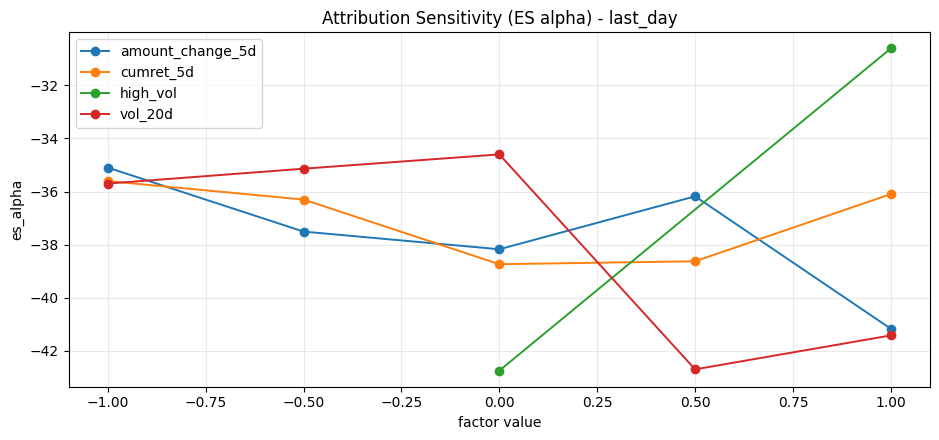

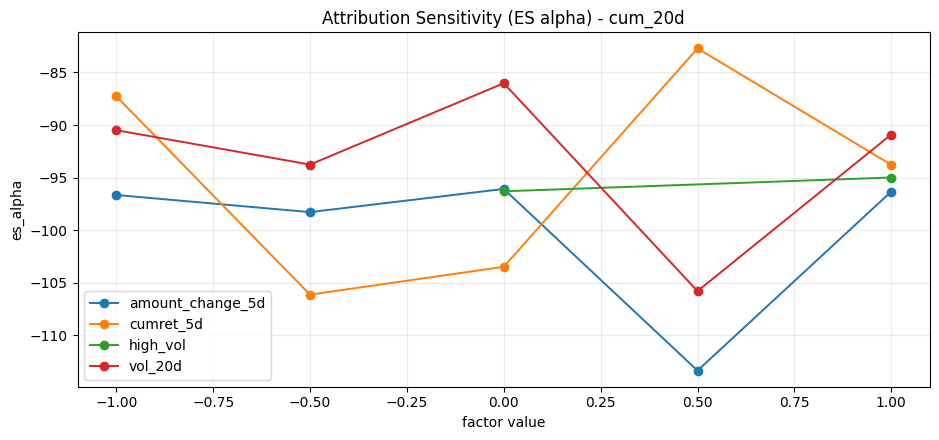

In [6]:
if not attr_available:
    print('Attribution outputs are not present in live outputs/tables. Calibration is evaluation-only, so rerun attribution.py when attribution figures are needed.')
else:
    sub = attr_df[attr_df['factor'] != 'baseline'].copy()
    sub['factor_value'] = sub['factor_value'].astype(float)
    display(attr_df.head(12))
    for hz in ['last_day', 'cum_20d']:
        hz_df = sub[sub['horizon'] == hz]
        fig, ax = plt.subplots(figsize=(9.5, 4.5))
        for factor, g in hz_df.groupby('factor'):
            g = g.sort_values('factor_value')
            ax.plot(g['factor_value'], g['es_alpha'], marker='o', linewidth=1.4, label=factor)
        ax.set_title(f'Attribution Sensitivity (ES alpha) - {hz}')
        ax.set_xlabel('factor value')
        ax.set_ylabel('es_alpha')
        ax.grid(alpha=0.25)
        ax.legend()
        plt.tight_layout()
        plt.show()


## 5) Reading the exported figures in context

The saved PNG files are best used after the tabular interpretation above.

Why:
- Without the table reading, the plots may look visually impressive but analytically ambiguous.
- After the table reading, the figures become evidence for a precise conclusion: the pipeline is complete, the evaluation is functioning, and the model still needs calibration work.
- After the calibration round, the correct presentation style is to show the two anchor runs side by side rather than pretending there is a single universally best model.

That is the correct narrative for the current state of the project.


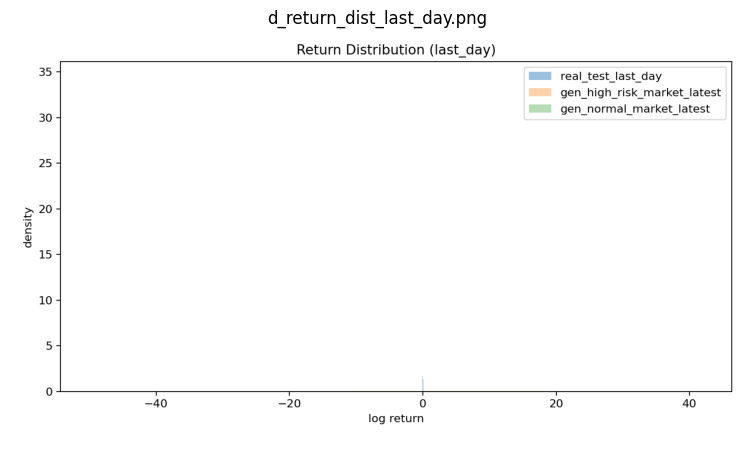

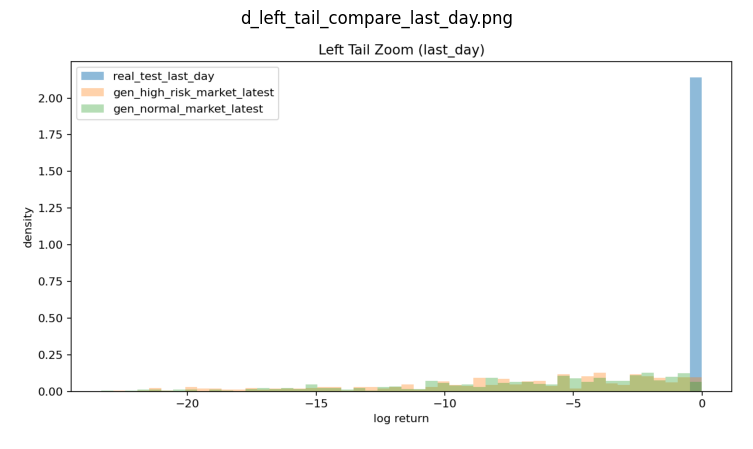

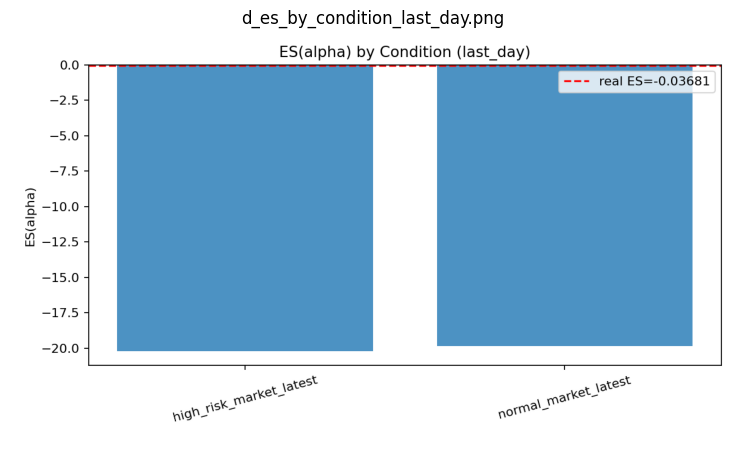

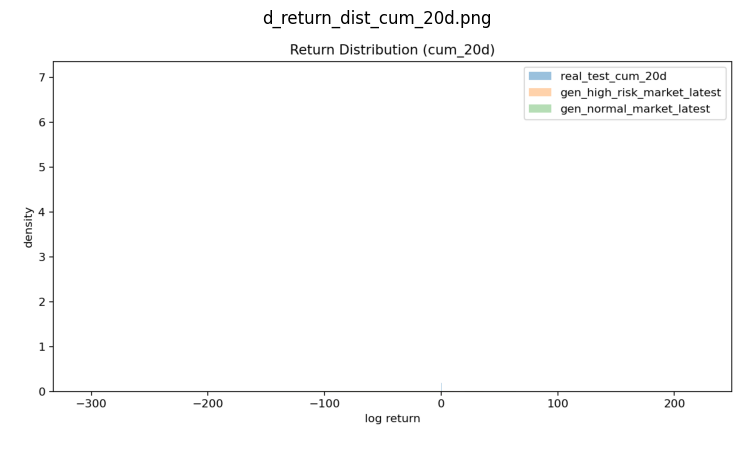

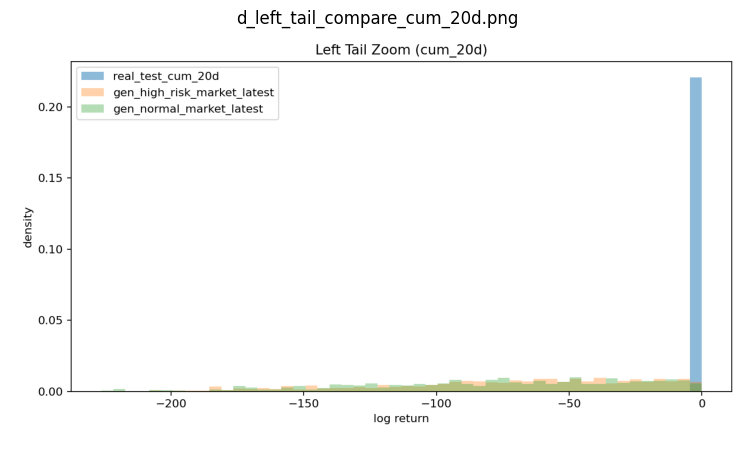

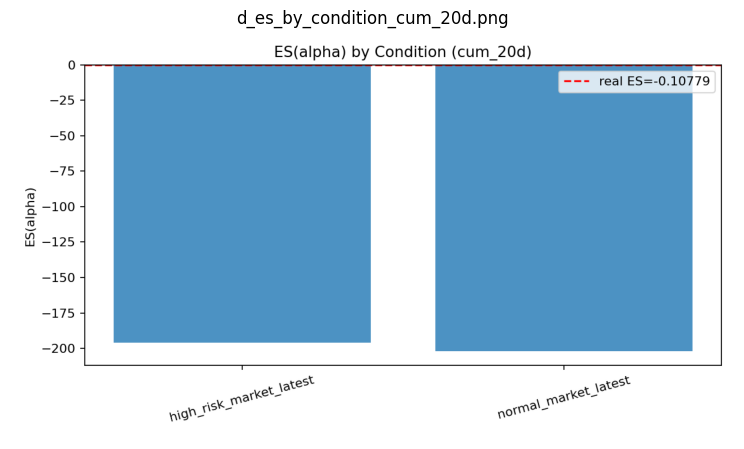

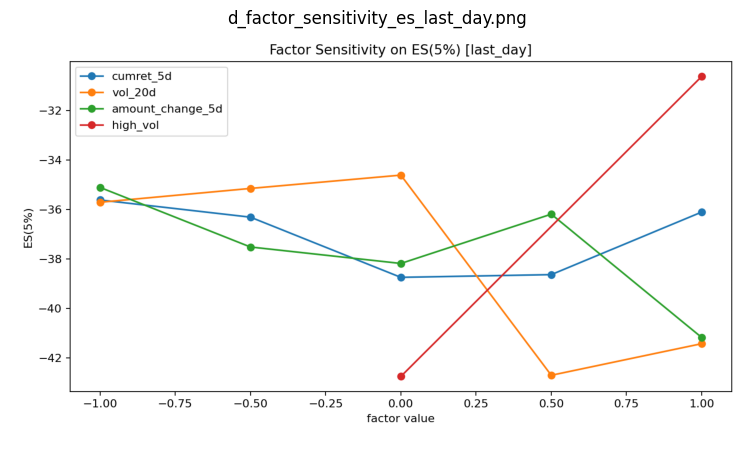

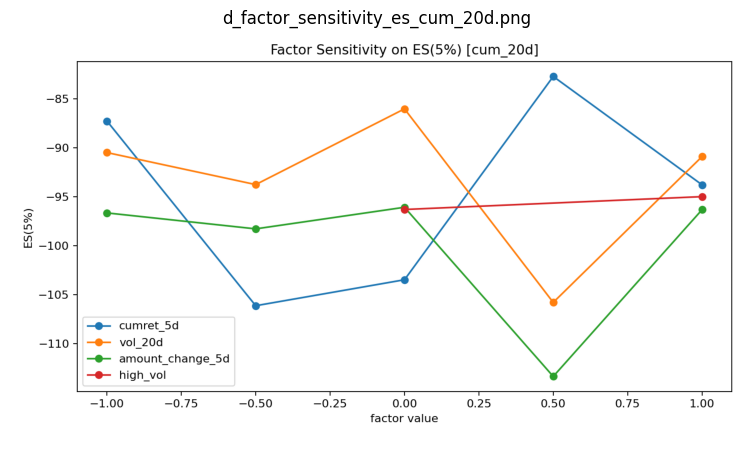

In [7]:
img_names = [
    'd_return_dist_last_day.png',
    'd_left_tail_compare_last_day.png',
    'd_es_by_condition_last_day.png',
    'd_return_dist_cum_20d.png',
    'd_left_tail_compare_cum_20d.png',
    'd_es_by_condition_cum_20d.png',
    'd_factor_sensitivity_es_last_day.png',
    'd_factor_sensitivity_es_cum_20d.png',
]

for name in img_names:
    p = FIG_DIR / name
    if not p.exists():
        print(f'[missing] {p}')
        continue
    img = plt.imread(p)
    plt.figure(figsize=(9.5, 4.6))
    plt.imshow(img)
    plt.title(name)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


## 6) What D-module has already delivered to the full project

The correct project-level conclusion is now clearer than before.

D-module has already delivered:
- Reproducible risk tables.
- Real-versus-generated distribution diagnostics.
- Condition-level sensitivity analysis.
- A calibration decision boundary rather than a single overconfident winner.

The practical next-step framing is now explicit:
- If the project prioritizes overall distribution fit, continue from `seed_42_tailw_1.0`.
- If the project prioritizes ES alignment to real data, continue from `seed_42_tailw_3.0`.
- If both objectives must improve together, the next stage should move to condition expansion or backbone upgrade rather than more seed and tail-weight tuning.

That is a strong D-module outcome. The evaluation layer is no longer just saying that the model is imperfect. It is telling the project exactly what kind of imperfection remains and what the next engineering decision should be.
